# SNR Per-Crack Interactive Analysis

This notebook starts from a `snr_per_crack_*.csv` file exported by the Scanimator workflow.

Workflow:
1. Select one per-crack CSV file
2. Load the per-crack dataframe (`per_crack_df`)
3. Detect factors for data analysis

In [11]:
from pathlib import Path
from datetime import datetime

import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 200)

In [12]:
# Input controls
USE_GUI_PICKER = True
CSV_GLOB_PATTERN = "outputs/run_*/snr_per_crack*.csv"

# Optional: set an exact file path. If set, this takes priority over picker/glob.
PER_CRACK_CSV_PATH = None  # Example: "outputs/run_20260525_140100/snr_per_crack_20260525_140100.csv"

# When using glob, choose the newest matching file automatically.
PICK_MOST_RECENT_FROM_GLOB = True

In [42]:
# Load per-crack CSV produced by Scanimator and add data analysis factors
selected_path = None
matches = sorted(Path.cwd().glob(CSV_GLOB_PATTERN))

if PER_CRACK_CSV_PATH:
    selected_path = Path(PER_CRACK_CSV_PATH)
elif USE_GUI_PICKER:
    import tkinter as tk
    from tkinter import filedialog

    root = tk.Tk()
    root.withdraw()
    root.attributes("-topmost", True)
    try:
        picked = filedialog.askopenfilename(
            title="Select snr_per_crack CSV",
            initialdir=str((Path.cwd() / "outputs").resolve()),
            filetypes=[("CSV files", "*.csv"), ("All files", "*.*")],
        )
        if picked:
            selected_path = Path(picked)
    finally:
        root.destroy()

if selected_path is None and matches:
    selected_path = matches[-1] if PICK_MOST_RECENT_FROM_GLOB else matches[0]

if selected_path is None:
    raise FileNotFoundError(f"No CSV file was selected or matched: {CSV_GLOB_PATTERN}")

per_crack_df = pd.read_csv(selected_path)

def derive_factor_groups(file_value):
    name = str(file_value).lower()

    material = None
    if "alum" in name or "aluminum" in name:
        material = "Aluminum"
    elif "ss" in name or "steel" in name:
        material = "Stainless Steel"
    elif "titan" in name:
        material = "Titanium"

    frequency = None
    if "1.1mhz" in name or "1_1mhz" in name or "1.1" in name:
        frequency = "1.1"
    elif "2.4mhz" in name or "2_4mhz" in name or "2.4" in name:
        frequency = "2.4"
    elif "3.2mhz" in name or "3_2mhz" in name or "3.2" in name:
        frequency = "3.2"
    else:
        frequency = "3.2"

    inductor = None
    if "flex08" in name:
        inductor = "8-layer"
    elif "flex04" in name:
        inductor = "4-layer"
    elif "flex12" in name:
        inductor = "12-layer"

    return pd.Series({
        "Material": material,
        "Frequency": frequency,
        "Inductor": inductor,
    })

factor_groups = per_crack_df["file"].apply(derive_factor_groups)
per_crack_df = pd.concat([per_crack_df, factor_groups], axis=1)

# If the CSV has a frequency column, use it as the primary Frequency source.
raw_frequency_col = next(
    (c for c in per_crack_df.columns if str(c).strip().lower() == "frequency" and c != "Frequency"),
    None,
)
if raw_frequency_col is not None:
    csv_frequency = per_crack_df[raw_frequency_col]
    csv_text = csv_frequency.astype(str).str.strip()
    csv_missing = csv_frequency.isna() | csv_text.eq("") | csv_text.eq("nan") | csv_text.eq("none")

    derived_frequency = per_crack_df["Frequency"] if "Frequency" in per_crack_df.columns else pd.Series(index=per_crack_df.index, dtype=object)
    final_frequency = csv_frequency.astype(object)
    final_frequency = final_frequency.where(~csv_missing, derived_frequency.astype(object))
    per_crack_df["Frequency"] = final_frequency

keep_columns = [
    "file", "manual_label", "peak_x", "peak_y", "noise_floor",
    "noise_sigma", "peak_signal_amplitude", "peak_snr_linear", "peak_snr_db",
    "Material", "Frequency", "Inductor",
]
per_crack_df = per_crack_df[[c for c in keep_columns if c in per_crack_df.columns]]

print("Added factor-group columns: Material, Frequency, Inductor")
print("per_crack_df shape:", per_crack_df.shape)
display(per_crack_df.head(20))

Added factor-group columns: Material, Frequency, Inductor
per_crack_df shape: (54, 12)


,file,manual_label,peak_x,peak_y,noise_floor,noise_sigma,peak_signal_amplitude,peak_snr_linear,peak_snr_db,Material,Frequency,Inductor
0,1.1mhz_alum.csv,Crack 1,9299.545,44.548786,44.480344,0.002284,0.068442,29.965667,29.532479,Aluminum,1.1,NaN
1,1.1mhz_alum.csv,Crack 1,9305.525,44.552521,44.480159,0.002284,0.072362,31.681741,30.016181,Aluminum,1.1,NaN
2,1.1mhz_alum.csv,Crack 2,9258.006,44.738628,44.479147,0.002284,0.259481,113.607468,41.108138,Aluminum,1.1,NaN
3,1.1mhz_alum.csv,Crack 2,9267.012,44.735802,44.479757,0.002284,0.256045,112.102905,40.992337,Aluminum,1.1,NaN
4,1.1mhz_alum.csv,Crack 3,9201.410,44.987465,44.478531,0.002284,0.508934,222.824127,46.959244,Aluminum,1.1,NaN
5,1.1mhz_alum.csv,Crack 3,9209.913,44.994999,44.481033,0.002284,0.513966,225.027289,47.044704,Aluminum,1.1,NaN
6,1.1mhz_ss.csv,Crack 1,7334.274,45.619240,45.592649,0.004726,0.026591,5.626708,15.005087,Stainless Steel,1.1,NaN
7,1.1mhz_ss.csv,Crack 1,7358.163,45.620121,45.593266,0.004726,0.026855,5.682683,15.091068,Stainless Steel,1.1,NaN
8,1.1mhz_ss.csv,Crack 2,7375.270,45.763329,45.594093,0.004726,0.169236,35.811338,31.080411,Stainless Steel,1.1,NaN
9,1.1mhz_ss.csv,Crack 2,7431.109,45.765656,45.595370,0.004726,0.170286,36.033525,31.134135,Stainless Steel,1.1,NaN


Produce visualizations based on the factors in the file

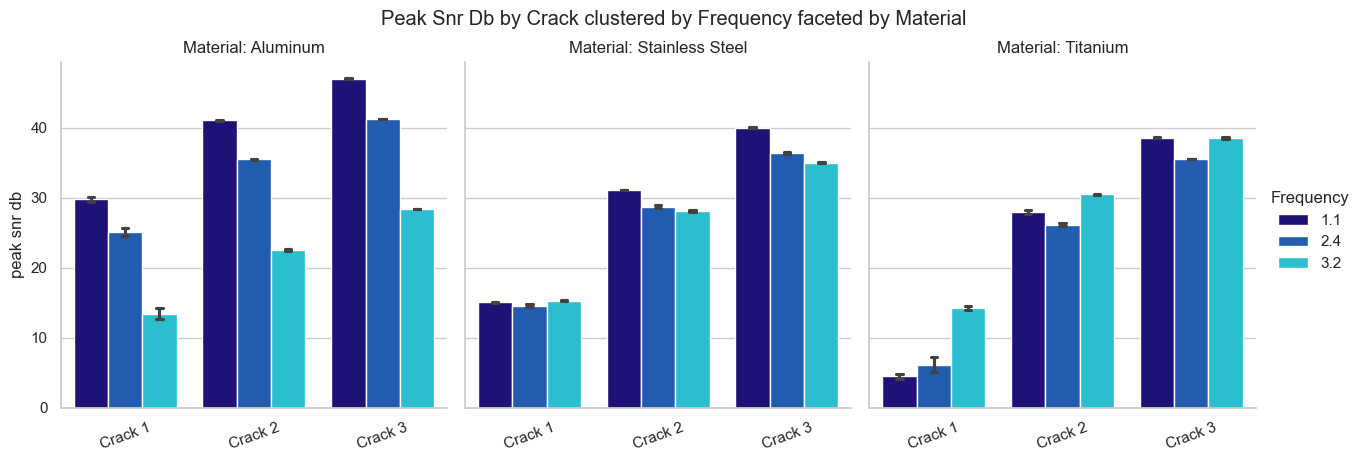

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
from datetime import datetime
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages
import config as cfg

cfg = importlib.reload(cfg)
LABEL_COLOR_MAP = getattr(cfg, "LABEL_COLOR_MAP", {})
FREQUENCY_COLOR_MAP = getattr(cfg, "FREQUENCY_COLOR_MAP", {})
MATERIAL_COLOR_MAP = getattr(cfg, "MATERIAL_COLOR_MAP", {})
INDUCTOR_COLOR_MAP = getattr(cfg, "INDUCTOR_COLOR_MAP", {})
CRACK_COLOR_MAP = getattr(cfg, "CRACK_COLOR_MAP", {})

# Choose what to plot here.
# GROUP_BY = x-axis, CLUSTER_BY = legend/hue, FACET_BY = column facets.
GROUP_BY = "Crack"      # Examples: "Material", "Frequency", "Inductor", "Crack"
CLUSTER_BY = "Frequency"     # Set to None to disable clustering.
FACET_BY = "Material"   # Set to None to disable faceting.
VALUE_COL = "peak_snr_db"
PLOT_KIND = "bar"        # bar, box, violin, strip, swarm
ESTIMATOR = "mean"       # Used for bar-like plots.
ERRORBAR = "sd"          # Used for bar-like plots.
CAPSIZE = 0.15
ROTATE_X_LABELS = 20
SAVE_PDF = False

plot_df = per_crack_df.copy()

def derive_factor_groups(file_value):
    name = str(file_value).lower()

    material = None
    if "alum" in name or "aluminum" in name:
        material = "Aluminum"
    elif "ss" in name or "steel" in name:
        material = "Stainless Steel"
    elif "titan" in name:
        material = "Titanium"

    frequency = None
    if "1.1mhz" in name or "1_1mhz" in name or "1.1" in name:
        frequency = "1.1"
    elif "2.4mhz" in name or "2_4mhz" in name or "2.4" in name:
        frequency = "2.4"
    elif "3.2mhz" in name or "3_2mhz" in name or "3.2" in name:
        frequency = "3.2"

    inductor = None
    if "flex_04" in name or "flex04" in name or "04_" in name:
        inductor = "4-layer"
    elif "flex_08" in name or "flex08" in name or "08_" in name:
        inductor = "8-layer"
    elif "flex_12" in name or "flex12" in name or "12_" in name:
        inductor = "12-layer"

    return pd.Series({
        "Material": material,
        "Frequency": frequency,
        "Inductor": inductor,
    })

for factor_column in ["Material", "Frequency", "Inductor"]:
    if factor_column not in plot_df.columns or plot_df[factor_column].dropna().empty:
        if "file" in plot_df.columns:
            factor_values = plot_df["file"].apply(derive_factor_groups)[factor_column]
            plot_df[factor_column] = factor_values

if "Crack" not in plot_df.columns:
    if "manual_label" in plot_df.columns:
        plot_df["Crack"] = plot_df["manual_label"]
    else:
        raise KeyError("Need a Crack or manual_label column to plot by crack label.")

def crack_size_key(label):
    text = str(label)
    lower = text.lower()
    if "not" in lower:
        return (99, lower)
    digits = "".join(ch for ch in text if ch.isdigit())
    if digits:
        return (int(digits), lower)
    return (98, lower)

def ordered_values(column_name):
    if column_name is None:
        return None
    if column_name not in plot_df.columns:
        raise KeyError(f"Column {column_name!r} is not available in per_crack_df.")

    values = plot_df[column_name].dropna().astype(str).tolist()
    if not values:
        return []

    unique_values = list(dict.fromkeys(values))
    if column_name == "Crack":
        preferred = ["Crack 1", "Crack 2", "Crack 3"]
        ordered = [value for value in preferred if value in unique_values]
        return ordered or sorted(unique_values, key=crack_size_key)
    if column_name == "Material":
        preferred = ["Aluminum", "Stainless Steel", "Titanium"]
        ordered = [value for value in preferred if value in unique_values]
        return ordered or sorted(unique_values)
    if column_name == "Frequency":
        preferred = ["1.1", "2.4", "3.2"]
        ordered = [value for value in preferred if value in unique_values]
        return ordered or sorted(unique_values)
    if column_name == "Inductor":
        preferred = ["4-layer", "8-layer", "12-layer"]
        ordered = [value for value in preferred if value in unique_values]
        return ordered or sorted(unique_values)
    return sorted(unique_values)

def palette_for(column_name, order):
    if column_name is None or not order:
        return None

    if column_name == "Crack":
        base_map = {**LABEL_COLOR_MAP, **CRACK_COLOR_MAP}
    elif column_name == "Material":
        base_map = MATERIAL_COLOR_MAP
    elif column_name == "Frequency":
        base_map = FREQUENCY_COLOR_MAP
    elif column_name == "Inductor":
        base_map = INDUCTOR_COLOR_MAP
    else:
        base_map = {}

    fallback_palette = sns.color_palette("tab10", n_colors=max(len(order), 1))
    return {value: base_map.get(value, fallback_palette[index % len(fallback_palette)]) for index, value in enumerate(order)}

plot_columns = [GROUP_BY, CLUSTER_BY, FACET_BY]
for column_name in plot_columns:
    if column_name is not None and column_name not in plot_df.columns:
        raise KeyError(f"Column {column_name!r} is not available in per_crack_df.")

plot_data = plot_df.copy()
for column_name in plot_columns:
    if column_name is not None:
        plot_data[column_name] = plot_data[column_name].astype(str)

group_order = ordered_values(GROUP_BY)
cluster_order = ordered_values(CLUSTER_BY)
facet_order = ordered_values(FACET_BY)

if GROUP_BY is not None and not group_order:
    raise ValueError(f"No usable values found for GROUP_BY={GROUP_BY!r}.")
if CLUSTER_BY is not None and not cluster_order:
    raise ValueError(f"No usable values found for CLUSTER_BY={CLUSTER_BY!r}.")
if FACET_BY is not None and not facet_order:
    raise ValueError(f"No usable values found for FACET_BY={FACET_BY!r}.")

plot_palette = palette_for(CLUSTER_BY, cluster_order)
title_parts = [VALUE_COL.replace("_", " ").title(), f"by {GROUP_BY}"]
if CLUSTER_BY is not None:
    title_parts.append(f"clustered by {CLUSTER_BY}")
if FACET_BY is not None:
    title_parts.append(f"faceted by {FACET_BY}")
plot_title = " ".join(title_parts)

sns.set_theme(style="whitegrid")
plot_kwargs = dict(
    data=plot_data,
    x=GROUP_BY,
    y=VALUE_COL,
    kind=PLOT_KIND,
    order=group_order,
    estimator=ESTIMATOR,
    errorbar=ERRORBAR,
    capsize=CAPSIZE,
    height=4.5,
    aspect=0.95,
    sharey=True,
)
if CLUSTER_BY is not None:
    plot_kwargs["hue"] = CLUSTER_BY
    plot_kwargs["hue_order"] = cluster_order
    if plot_palette is not None:
        plot_kwargs["palette"] = plot_palette
if FACET_BY is not None:
    plot_kwargs["col"] = FACET_BY
    plot_kwargs["col_order"] = facet_order

g = sns.catplot(**plot_kwargs)
g.set_axis_labels("", VALUE_COL.replace("_", " "))
if FACET_BY is not None:
    g.set_titles(f"{FACET_BY}: {{col_name}}")
g.fig.suptitle(plot_title, y=1.03)
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=ROTATE_X_LABELS)

pdf_dir = Path("outputs") / "reports"
pdf_dir.mkdir(parents=True, exist_ok=True)
pdf_path = pdf_dir / f"snr_custom_plot_{datetime.now():%Y%m%d_%H%M%S}.pdf"
if SAVE_PDF:
    with PdfPages(pdf_path) as pdf:
        pdf.savefig(g.fig, bbox_inches="tight")
    print(f"Saved plot PDF: {pdf_path}")

plt.show()